# Heart Disease Risk Prediction

## Objective
To predict the likelihood of heart disease in patients using clinical features and compare the performance of multiple machine learning models.

## Dataset
Cleveland Heart Disease dataset containing 13 clinical features including age, cholesterol, chest pain type, and maximum heart rate.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('C:\\Users\\yprad\\OneDrive\\Desktop\\heart.csv.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [8]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

## Exploratory Data Analysis
Understanding the distribution of key clinical features and their relationship with heart disease.

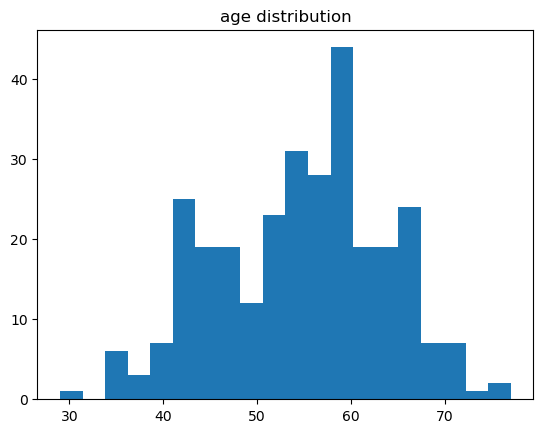

In [9]:
plt.hist(df['age'],bins=20)
plt.title("age distribution")
plt.show()

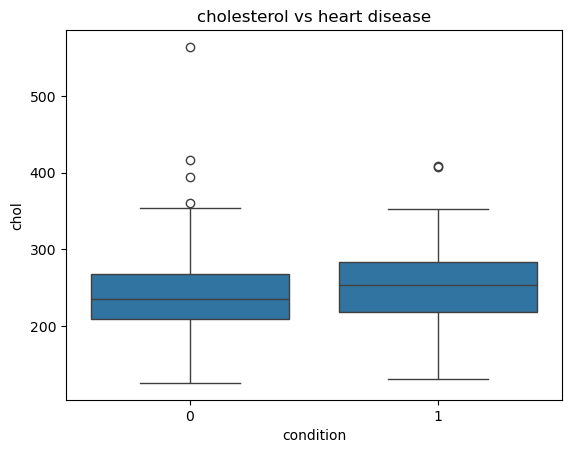

In [13]:
sns.boxplot(x='condition',y='chol',data=df)
plt.title("cholesterol vs heart disease")
plt.show()

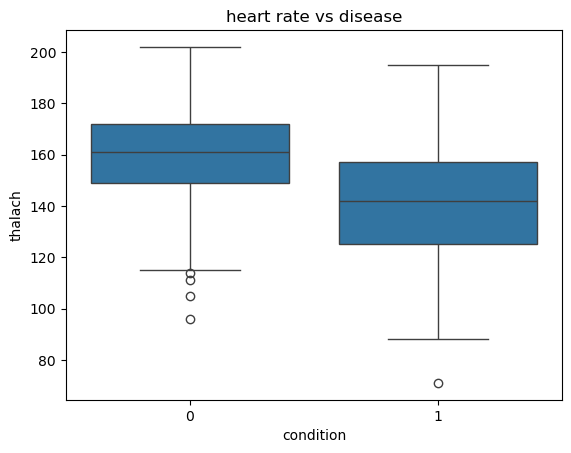

In [14]:
sns.boxplot(x='condition',y='thalach',data=df)
plt.title("heart rate vs disease")
plt.show()

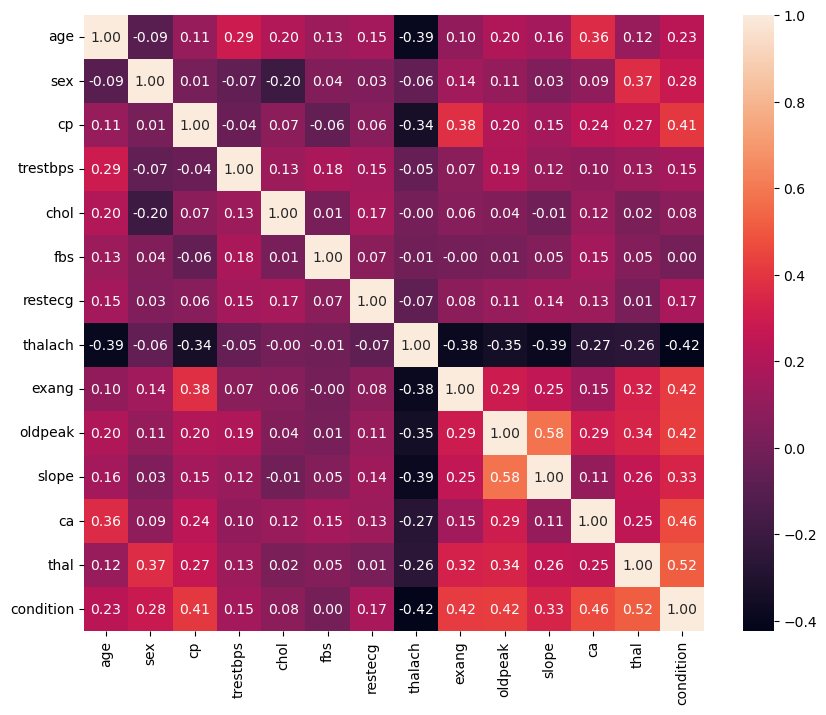

In [4]:

df=pd.read_csv('C:\\Users\\yprad\\OneDrive\\Desktop\\heart.csv.csv')
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,fmt=".2f")
df=pd.read_csv('C:\\Users\\yprad\\OneDrive\\Desktop\\heart.csv.csv')
plt.show()

## Model Building and Evaluation
Three classification models are trained and compared to identify the best approach for heart disease prediction.

In [21]:

df=pd.read_csv('C:\\Users\\yprad\\OneDrive\\Desktop\\heart.csv.csv')
x=df.drop("condition",axis=1)
y=df["condition"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train,y_train)
acc1=model1.score(x_test,y_test)
print("LogisticRegression accuracy",acc1)

LogisticRegression accuracy 0.7333333333333333


In [23]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier()
model2.fit(x_train,y_train)
acc2=model2.score(x_test,y_test)
print("DecisionTreeClassifier accuracy",acc2)

DecisionTreeClassifier accuracy 0.7166666666666667


In [27]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier()
model3.fit(x_train,y_train)
acc3=model3.score(x_test,y_test)
print("RandomForestClassifier accuracy",acc3)

RandomForestClassifier accuracy 0.7333333333333333


In [28]:
results=pd.DataFrame({"Model":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier"],"Accuracy":[acc1,acc2,acc3]})
print(results)

                    Model  Accuracy
0      LogisticRegression  0.733333
1  DecisionTreeClassifier  0.716667
2  RandomForestClassifier  0.733333


## Feature Selection
Using SelectKBest with chi-squared test to identify the most clinically significant features.

In [31]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
selector = SelectKBest(chi2, k=8)
x_new = selector.fit_transform(x_scaled, y)
selected_features = x.columns[selector.get_support()]
print("Selected features:", list(selected_features))
x_train, x_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

Selected features: ['sex', 'cp', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [32]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train,y_train)
acc1=model1.score(x_test,y_test)
print("LogisticRegression accuracy",acc1)

LogisticRegression accuracy 0.7833333333333333


In [33]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier()
model2.fit(x_train,y_train)
acc2=model2.score(x_test,y_test)
print("DecisionTreeClassifier accuracy",acc2)

DecisionTreeClassifier accuracy 0.7333333333333333


In [34]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier()
model3.fit(x_train,y_train)
acc3=model3.score(x_test,y_test)
print("RandomForestClassifier accuracy",acc3)

RandomForestClassifier accuracy 0.8166666666666667


In [35]:
results=pd.DataFrame({"Model":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier"],"Accuracy":[acc1,acc2,acc3]})
print(results)

                    Model  Accuracy
0      LogisticRegression  0.783333
1  DecisionTreeClassifier  0.733333
2  RandomForestClassifier  0.816667


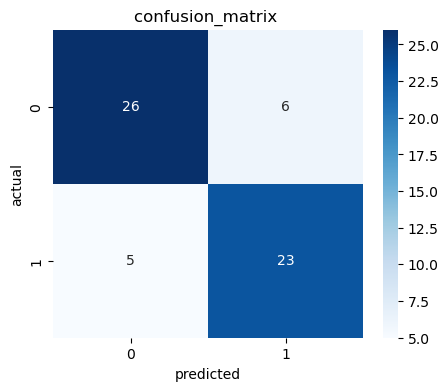

              precision    recall  f1-score   support

           0       0.84      0.81      0.83        32
           1       0.79      0.82      0.81        28

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60



In [36]:
from sklearn.metrics import classification_report,confusion_matrix 
import seaborn as sns
import matplotlib.pyplot as plt
y_pred=model3.predict(x_test)

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("confusion_matrix ")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

print(classification_report(y_test,y_pred))

In [43]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy Before ": [0.733, 0.716, 0.733],
    "Accuracy After ": [0.780, 0.733, 0.810]
})
print(results)

                 Model  Accuracy Before   Accuracy After 
0  Logistic Regression             0.733            0.780
1        Decision Tree             0.716            0.733
2        Random Forest             0.733            0.810


## Conclusion
After applying chi-squared feature selection, Random Forest achieved the best accuracy of 81%, 
up from 73.3% baseline. Key clinical features identified include chest pain type, thal, ca, 
oldpeak and slope. Future work could explore hyperparameter tuning and cross-validation.